# 04 — Cleaning and network-wide fault flagging

Apply the Byrne (2023) quality rule (imported from `src/cleaning.py`) to every sensor. Flags rows rather than deleting them. Produces per-sensor cleaned Parquet in `data/processed/cleaned/`, a network cleaning summary, and a fault-candidate table sorted by A/B disagreement — the first deliverable for the fault-detection objective.

The summary separates **high-band** A/B disagreement (likely genuine hardware fault) from **low-band** disagreement (noise-prone near-clean air), so the ranking isn't distorted by threshold artefacts at low concentrations.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # so `from src...` works from notebooks/
from src.config import *
import pandas as pd
import numpy as np
from src.cleaning import clean_sensor

# 3 sensors to sanity-check the rule before the batch
sl001 = pd.read_parquet(PROCESSED / "SL001_Sunnyview_Terrace.parquet")
sl026 = pd.read_parquet(PROCESSED / "SL026.parquet")
sl030 = pd.read_parquet(PROCESSED / "SL030.parquet")
print("SL001:", len(sl001), "  SL026:", len(sl026), "  SL030:", len(sl030))

SL001: 1038078   SL026: 952794   SL030: 12491


### Duplicate-timestamp check
Understand whether repeated timestamps exist before relying on `drop_duplicates`.

In [2]:
def duplicate_report(df, name):
    full_dups = df.duplicated(keep=False).sum()
    ts_dups   = df.duplicated(subset=[DATE_COL], keep=False).sum()
    print(f"=== {name} ===")
    print(f"  total rows:            {len(df):,}")
    print(f"  fully identical rows:  {full_dups:,}")
    print(f"  duplicated timestamps: {ts_dups:,}\n")

for nm, d in [("SL001", sl001), ("SL026", sl026), ("SL030", sl030)]:
    duplicate_report(d, nm)

=== SL001 ===
  total rows:            1,038,078
  fully identical rows:  49
  duplicated timestamps: 49

=== SL026 ===
  total rows:            952,794
  fully identical rows:  0
  duplicated timestamps: 0

=== SL030 ===
  total rows:            12,491
  fully identical rows:  0
  duplicated timestamps: 0



### Sanity-check the rule on the three samples
`clean_sensor` is defined once in `src/cleaning.py` and imported — the notebook never redefines it.

In [3]:
for name, df_raw in [("SL001", sl001), ("SL026", sl026), ("SL030", sl030)]:
    cleaned, n_dups = clean_sensor(df_raw)
    n, clean_n = len(cleaned), cleaned["is_clean"].sum()
    print(f"=== {name} ===")
    print(f"  duplicates removed:    {n_dups:,}")
    print(f"  flagged implausible:   {cleaned['flag_implausible'].sum():,}")
    print(f"  flagged A/B disagree:  {cleaned['flag_ab'].sum():,}")
    print(f"  CLEAN rows:            {clean_n:,} / {n:,}  ({clean_n/n*100:.1f}%)")
    raw_max   = df_raw[PM_A].max()
    clean_max = cleaned.loc[cleaned["is_clean"], PM_A].max()
    print(f"  PM2.5 A max:  raw {raw_max:.1f}  ->  clean {clean_max:.1f}\n")

=== SL001 ===
  duplicates removed:    38
  flagged implausible:   173,199
  flagged A/B disagree:  599,972
  CLEAN rows:            438,067 / 1,038,040  (42.2%)
  PM2.5 A max:  raw 3402.1  ->  clean 731.3

=== SL026 ===
  duplicates removed:    0
  flagged implausible:   0
  flagged A/B disagree:  533,721
  CLEAN rows:            419,073 / 952,794  (44.0%)
  PM2.5 A max:  raw 409.5  ->  clean 409.5

=== SL030 ===
  duplicates removed:    0
  flagged implausible:   0
  flagged A/B disagree:  4,138
  CLEAN rows:            8,353 / 12,491  (66.9%)
  PM2.5 A max:  raw 72.6  ->  clean 40.4



### Network-wide cleaning
Run the rule over every sensor Parquet, write cleaned copies, and build the summary + fault table. Paths come from `config` — no hardcoded absolute paths.

In [4]:
rows = []
sensor_files = sorted(PROCESSED.glob("*.parquet"))
print(f"found {len(sensor_files)} sensor files")

for path in sensor_files:
    name = path.stem
    df_raw = pd.read_parquet(path)
    if PM_A not in df_raw.columns or PM_B not in df_raw.columns:
        print(f"  ! {name}: missing PM columns, skipped"); continue

    cleaned, n_dups = clean_sensor(df_raw)
    cleaned.to_parquet(CLEANED / f"{name}.parquet", index=False)

    a, b   = cleaned[PM_A], cleaned[PM_B]
    higher = np.maximum(a, b)
    ab_high = (cleaned["flag_ab"] & (higher >  PM_BREAK)).sum()   # fault signal
    ab_low  = (cleaned["flag_ab"] & (higher <= PM_BREAK)).sum()   # noise-prone

    rows.append({
        "sensor": name, "rows": len(cleaned), "duplicates": n_dups,
        "n_implausible": int(cleaned["flag_implausible"].sum()),
        "n_ab_total":    int(cleaned["flag_ab"].sum()),
        "n_ab_highband": int(ab_high),
        "n_ab_lowband":  int(ab_low),
        "n_clean":       int(cleaned["is_clean"].sum()),
        "pct_clean":     round(cleaned["is_clean"].mean() * 100, 1),
        "pct_ab_flag":   round(cleaned["flag_ab"].mean() * 100, 1),
        "pm_a_max_raw":  round(df_raw[PM_A].max(), 1),
        "pm_a_max_clean":round(cleaned.loc[cleaned["is_clean"], PM_A].max(), 1),
    })
    print(f"  {name}: {len(cleaned):,} rows, {rows[-1]['pct_clean']}% clean")

found 50 sensor files
  ! daily_matrix: missing PM columns, skipped
  ! network_hourly_median: missing PM columns, skipped


  ! network_hourly_sensors: missing PM columns, skipped
  SL001_Sunnyview_Terrace: 1,038,040 rows, 42.2% clean
  SL003_Corn_Exchange_Cabinet: 575,919 rows, 54.8% clean
  SL005_Kirkstall_Valley_Primary: 523,788 rows, 67.6% clean
  SL006: 1,051,414 rows, 58.8% clean
  SL007_Ninelands_Primary: 1,040,858 rows, 63.0% clean
  SL008_Westgate_Primary: 771,477 rows, 51.5% clean
  SL009: 168,047 rows, 63.8% clean
  SL011: 822,598 rows, 49.6% clean
  SL012_Morley: 934,506 rows, 72.0% clean
  SL015_-_Garforth_Main_Street: 417,632 rows, 71.0% clean
  SL016_Scholes_Main_Street: 729,334 rows, 74.6% clean
  SL018_East_Ardsley_A650: 632,321 rows, 35.5% clean
  SL019_Cornwall_Crescent_Rothwell: 735,362 rows, 71.7% clean
  SL020: 627,860 rows, 68.6% clean
  SL021_Kippax_Church_Lane: 586,423 rows, 52.4% clean
  SL022_Church_Lane_Horsforth: 507,381 rows, 71.6% clean
  SL023_Nelson_Street_Otley: 276,076 rows, 59.9% clean
  SL024_Wetherby_Town_Centre: 1,007,244 rows, 73.8% clean
  SL025_-_Oakwood: 964,656 ro

### Network summary + fault-candidate table
Sorted by A/B-disagreement rate. The `n_ab_highband` column is the honest fault signal.

In [5]:
summary = pd.DataFrame(rows).sort_values("pct_ab_flag", ascending=False)
summary.to_csv(OUT_TABLES / "cleaning_summary.csv", index=False)

print("=== fault candidates (highest A/B-disagree rate) ===")
print(summary[["sensor", "rows", "pct_ab_flag", "n_ab_highband",
               "pct_clean", "pm_a_max_raw"]].head(10).to_string(index=False))

=== fault candidates (highest A/B-disagree rate) ===
                 sensor    rows  pct_ab_flag  n_ab_highband  pct_clean  pm_a_max_raw
                  SL037  901239         86.9         749842       13.1        3407.9
SL018_East_Ardsley_A650  632321         64.5         197616       35.5        3398.8
SL001_Sunnyview_Terrace 1038040         57.8         344196       42.2        3402.1
                  SL026  952794         56.0         192891       44.0         409.5
                  SL062  642630         53.4          99391       46.6         606.2
                  SL034  587907         51.6         206118       48.4        3396.9
                  SL044  863374         51.1         258538       48.9        3394.8
                  SL011  822598         50.4         173907       49.6        1429.1
                  SL032  188838         49.4          38281       50.6         360.3
 SL008_Westgate_Primary  771477         48.5         172051       51.5        3333.0


In [6]:
import pandas as pd
import numpy as np

# what counts as good coverage
EXPECTED_PER_HOUR = 30      # 60 min / 2-min interval = 30 readings per hour
HOURLY_MIN_FRAC   = 0.5     # an hour is "covered" if it has >=50% of expected readings

rows = []
for path in sorted(CLEANED.glob("*.parquet")):
    name  = path.stem
    df    = pd.read_parquet(path)
    clean = df[df["is_clean"]].copy()
    if clean.empty:
        continue
    clean[DATE_COL] = pd.to_datetime(clean[DATE_COL])

    ser = clean.set_index(DATE_COL)
    per_hour = ser[PM_A].resample("h").count()      # clean readings per hour

    rows.append({
        "sensor": name,
        "clean_rows": len(clean),
        "span_days": (clean[DATE_COL].max() - clean[DATE_COL].min()).days,
        "median_readings_per_hour": int(per_hour[per_hour > 0].median()),
        "pct_hours_well_covered": round(
            (per_hour >= EXPECTED_PER_HOUR * HOURLY_MIN_FRAC).mean() * 100, 1),
        "pct_rows_with_RH": round(clean[RH_COL].notna().mean() * 100, 1),
    })

cov = pd.DataFrame(rows).sort_values("pct_hours_well_covered", ascending=False)
cov.to_csv(OUT_TABLES / "coverage_check.csv", index=False)

print(cov.to_string(index=False))
print("\n--- network summary ---")
print(f"median % hours well-covered: {cov['pct_hours_well_covered'].median():.1f}%")
print(f"median % rows with RH:       {cov['pct_rows_with_RH'].median():.1f}%")
print(f"sensors with usable RH (>50%): {(cov['pct_rows_with_RH'] > 50).sum()} of {len(cov)}")

                          sensor  clean_rows  span_days  median_readings_per_hour  pct_hours_well_covered  pct_rows_with_RH
      SL024_Wetherby_Town_Centre      742885       1588                        25                    70.8             100.0
                    SL012_Morley      672597       1495                        24                    67.9             100.0
         SL007_Ninelands_Primary      655264       1601                        23                    60.3              99.1
                           SL035      410357       1096                        22                    59.0             100.0
    SL015_-_Garforth_Main_Street      296565        808                        23                    57.7             100.0
SL019_Cornwall_Crescent_Rothwell      527495       1400                        23                    57.7             100.0
        SL027_-_SEE_Building_new      609225       1585                        21                    56.4             100.0
        

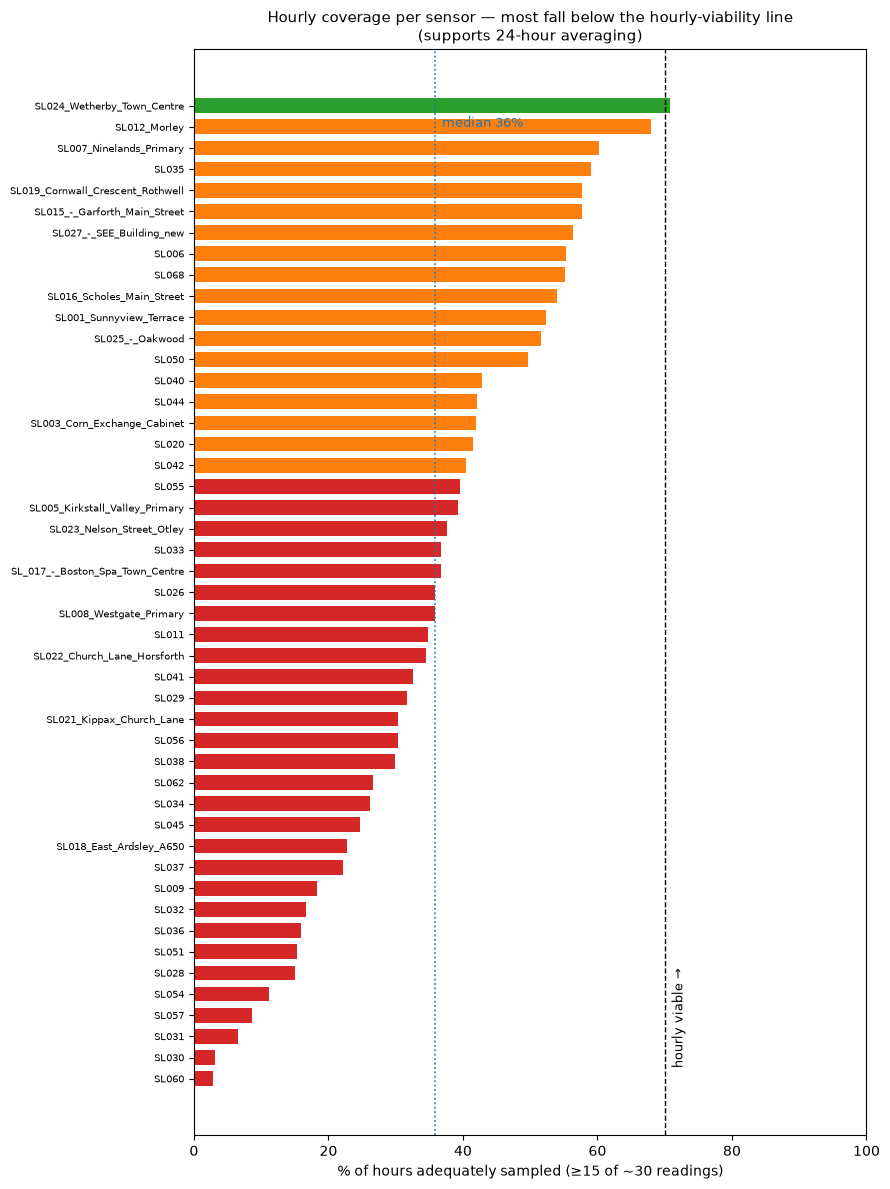

In [7]:
import matplotlib.pyplot as plt

# plot coverage per sensor
cov = pd.read_csv(OUT_TABLES / "coverage_check.csv") 
cov = cov.sort_values("pct_hours_well_covered")

THRESHOLD = 70   # rough hourly-viability line
colors = ["tab:green" if v >= THRESHOLD else ("tab:orange" if v >= 40 else "tab:red")
          for v in cov["pct_hours_well_covered"]]

fig, ax = plt.subplots(figsize=(9, 12))
ax.barh(cov["sensor"], cov["pct_hours_well_covered"], color=colors, height=0.7)

ax.axvline(THRESHOLD, color="black", ls="--", lw=1)
ax.text(THRESHOLD + 1, 0.5, "hourly viable →", fontsize=9, rotation=90, va="bottom")

med = cov["pct_hours_well_covered"].median()
ax.axvline(med, color="tab:blue", ls=":", lw=1.2)
ax.text(med + 1, len(cov) - 2, f"median {med:.0f}%", fontsize=9, color="tab:blue")

ax.set_xlabel("% of hours adequately sampled (≥15 of ~30 readings)")
ax.set_title("Hourly coverage per sensor — most fall below the hourly-viability line\n"
             "(supports 24-hour averaging)", fontsize=11)
ax.set_xlim(0, 100)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.savefig(OUT_FIGURES / "coverage_per_sensor.png", dpi=150, bbox_inches="tight")
plt.show()

### Sensitivity test: choosing `MIN_READ_PER_HOUR`

Is 15 readings the right bar for a valid hourly mean? The test: find hours where a sensor was fully online (>=28 of ~30 readings), so the true hourly mean is known. Then pretend the sensor was only online for a *contiguous* stretch of T readings, average that stretch, and measure the error against the truth. Contiguous stretches mimic real dropouts (a sensor offline for part of the hour), which is harsher and more realistic than random subsampling.

Every sensor in the network contributes, capped at 300 complete hours each so that long-lived sensors do not dominate. The output is one table per threshold value: the error a partial hour carries, next to the coverage that threshold keeps.

In [8]:
import numpy as np
import pandas as pd

THRESHOLDS = [5, 7, 10, 15, 20, 25]
FULL_HOUR = 28          # an hour with >= this many of ~30 readings counts as complete
PER_SENSOR_HOURS = 300  # cap per sensor, so long-lived sensors don't dominate
MIN_TRUE_MEAN = 2.0     # skip near-zero hours where % error is meaningless

rng = np.random.default_rng(42)

abs_err = {t: [] for t in THRESHOLDS}
rel_err = {t: [] for t in THRESHOLDS}
coverage_rows = []
tested_per_sensor = {}

for path in sorted(CLEANED.glob("*.parquet")):
    df = pd.read_parquet(path, columns=[DATE_COL, PM_A, PM_B, "is_clean"])
    df = df[df["is_clean"]]
    if df.empty:
        continue

    ts = pd.to_datetime(df[DATE_COL], utc=True).dt.tz_localize(None)
    pm = ((df[PM_A] + df[PM_B]) / 2).to_numpy()
    order = np.argsort(ts.to_numpy())
    ts, pm = ts.to_numpy()[order], pm[order]
    hour = ts.astype("datetime64[h]")

    # coverage at each threshold
    counts = pd.Series(1, index=hour).groupby(level=0).size()
    span = int((hour.max() - hour.min()) / np.timedelta64(1, "h")) + 1
    coverage_rows.append(
        {"sensor": path.stem,
         **{t: 100 * (counts >= t).sum() / span for t in THRESHOLDS}})

    # contiguous-block subsampling inside complete hours
    full_hours = counts[counts >= FULL_HOUR].index.to_numpy()
    if len(full_hours) == 0:
        continue
    picked = rng.choice(full_hours, size=min(PER_SENSOR_HOURS, len(full_hours)),
                        replace=False)
    picked_set = set(picked)

    n_tested = 0
    s = pd.Series(pm, index=hour)
    for h, vals in s.groupby(level=0):
        if h not in picked_set:
            continue
        v = vals.to_numpy()
        true_mean = v.mean()
        if true_mean < MIN_TRUE_MEAN:
            continue
        for t in THRESHOLDS:
            start = rng.integers(0, len(v) - t + 1)
            sub_mean = v[start:start + t].mean()
            abs_err[t].append(abs(sub_mean - true_mean))
            rel_err[t].append(abs(sub_mean - true_mean) / true_mean)
        n_tested += 1
    if n_tested:
        tested_per_sensor[path.stem] = n_tested

print(f"sensors contributing complete hours: {len(tested_per_sensor)} "
      f"(of {len(coverage_rows)} with clean data)")
print(f"hours tested per threshold: {len(abs_err[THRESHOLDS[0]]):,}")
print(f"smallest / largest sensor contribution: "
      f"{min(tested_per_sensor.values())} / {max(tested_per_sensor.values())} hours")

cov_median = pd.DataFrame(coverage_rows).set_index("sensor").median()

result = pd.DataFrame({
    "typical error (\u00b5g/m\u00b3)":        [np.median(abs_err[t]) for t in THRESHOLDS],
    "typical error (%)":                        [100 * np.median(rel_err[t]) for t in THRESHOLDS],
    "worst-case error (%)":                     [100 * np.percentile(rel_err[t], 90) for t in THRESHOLDS],
    "hours kept, network median (%)":           [cov_median[t] for t in THRESHOLDS],
}, index=pd.Index(THRESHOLDS, name="readings required per hour")).round(1)

def highlight_chosen(row):
    style = "background-color: #fff3cd; font-weight: bold" if row.name == 15 else ""
    return [style] * len(row)

result.style.apply(highlight_chosen, axis=1).format(precision=1)


sensors contributing complete hours: 47 (of 47 with clean data)
hours tested per threshold: 6,557
smallest / largest sensor contribution: 18 / 247 hours


,typical error (µg/m³),typical error (%),worst-case error (%),"hours kept, network median (%)"
readings required per hour,,,,
5,0.5,7.0,26.4,52.3
7,0.4,6.4,24.3,49.3
10,0.4,5.5,20.1,44.0
15,0.3,4.1,15.6,35.9
20,0.2,2.8,10.1,28.0
25,0.1,1.4,5.0,18.5


**How to read this.** Each row is one candidate threshold. *Typical error* (the median) is how far a partial-hour mean usually sits from the truth; *worst-case* is the 90th percentile, worse than 9 in 10 tested hours. *Hours kept* is the coverage that threshold allows.\n
\n
The two halves pull in opposite directions: fewer required readings keeps more hours but each hour is less trustworthy. At the chosen value of **15** (half the nominal 30 readings, highlighted) the typical error is ~4% and the worst case ~16%, for 36% coverage. Relaxing all the way to 5 readings still recovers only ~52% of hours while letting the worst-case error grow past 25% \u2014 so even the most permissive rule leaves half the network's hours missing entirely. Hourly resolution fails in its best case, which is the quantitative basis for working at daily means, and 15 is retained as the hourly bar wherever hourly aggregates are needed (the event analysis in notebook 06).

In [9]:
import pandas as pd

THRESHOLDS = [30, 60, 120, 180, 240, 360]   # candidate min clean readings/day

per_sensor_days = {}
grand = {t: 0 for t in THRESHOLDS}

for path in sorted(CLEANED.glob("*.parquet")):
    name  = path.stem
    df    = pd.read_parquet(path)
    clean = df[df["is_clean"]].copy()
    if clean.empty:
        continue
    clean[DATE_COL] = pd.to_datetime(clean[DATE_COL])
    counts = clean.set_index(DATE_COL)[PM_A].resample("D").count()
    counts = counts[counts > 0]                 # active days only
    total  = len(counts)
    row = {t: int((counts >= t).sum()) for t in THRESHOLDS}
    per_sensor_days[name] = (total, row)
    for t in THRESHOLDS:
        grand[t] += row[t]

print("Network total valid sensor-days at each threshold:\n")
base = grand[THRESHOLDS[0]]
for t in THRESHOLDS:
    print(f"  >= {t:>3} readings/day: {grand[t]:>7,}  "
          f"({grand[t]/base*100:>5.1f}% of the >=30 baseline)")

# optional: how many sensors keep a usable record (say >=100 valid days) at each threshold
print("\nSensors retaining >=100 valid days:")
for t in THRESHOLDS:
    n = sum(1 for _, (_, row) in per_sensor_days.items() if row[t] >= 100)
    print(f"  >= {t:>3} readings/day: {n} sensors")

Network total valid sensor-days at each threshold:

  >=  30 readings/day:  35,035  (100.0% of the >=30 baseline)
  >=  60 readings/day:  34,402  ( 98.2% of the >=30 baseline)
  >= 120 readings/day:  33,188  ( 94.7% of the >=30 baseline)
  >= 180 readings/day:  31,738  ( 90.6% of the >=30 baseline)
  >= 240 readings/day:  29,786  ( 85.0% of the >=30 baseline)
  >= 360 readings/day:  23,956  ( 68.4% of the >=30 baseline)

Sensors retaining >=100 valid days:
  >=  30 readings/day: 44 sensors
  >=  60 readings/day: 43 sensors
  >= 120 readings/day: 43 sensors
  >= 180 readings/day: 43 sensors
  >= 240 readings/day: 43 sensors
  >= 360 readings/day: 42 sensors
